<a href="https://colab.research.google.com/github/b00001/sciusproject-hyperthermia/blob/main/week3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Magnetic Hyperthermia (LRT) — Material & frequency Study

Rosensweig 2002, JMMM 252:370 https://ui.adsabs.harvard.edu/abs/2002JMMM..252..370R/abstract

| Magnetic solid | Chemical formula | Ms (kA m−1) | K (kJ m−3) | c (J kg−1 K−1) | ρ (kg m−3) |
|---|---|---|---|---|---|
| Maghemite | γ-Fe2O3 | 414 | −4.6 | ∼746 | 4600 |
| Magnetite | FeO·Fe2O3 | 446 | 23–41 | 670 | 5180 |
| Cobalt ferrite | CoO·Fe2O3 | 425 | 180–200 | 700 | 4907 |
| Barium ferrite | BaO·6Fe2O3 | 380 | 300–330 | ∼650 | 5280 |

Magnetic nanoparticles placed in an alternating magnetic field release heat as
their magnetic moments repeatedly flip. This is the basis of **magnetic
hyperthermia** — a cancer therapy that heats tumors from the inside using
injected nanoparticles. The heat delivered per unit volume follows

$$P = \mu_0\, \pi\, f\, H_0^2\, \chi''$$

so the power depends on the driving frequency $f$, the field $H_0$, and the
imaginary susceptibility $\chi''$ — which itself depends on the particle radius
$R$ and the material.

We answer it with **Linear Response Theory** (Rosensweig 2002), valid in the
small-field limit ($\xi \leq 1$), across four candidate materials: maghemite,
magnetite, cobalt ferrite, and barium ferrite.

Everything you might want to change lives in the **single INPUT cell below**.
The rest of the notebook only reads those values, computes, and plots — so you
never edit anything past the input cell.

**How to use:** open the INPUT cell, edit the values, then Run All.

**Sections**
1. $\tau_{\text{eff}}$ vs $R$ — how fast the moments relax (all 4 materials)
2. $\chi''$ vs frequency — finding the best frequency for each size
3. Peak analysis of $\chi''$ — how the optimal frequency & height shift with $R$
4. Power $P$ vs frequency — why the best $\chi''$ isn't the whole story (analytic)
5. Power $P$ vs frequency — searching radius & frequency for the true maximum


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# ---- global plot fonts ----
plt.rcParams.update({
    'axes.titlesize': 20,    # graph title
    'axes.labelsize': 20,    # x/y axis labels
    'figure.titlesize': 20,  # suptitle
    'xtick.labelsize': 14,   # scale numbers
    'ytick.labelsize': 14,
})

# =====================================================================
#  ALL INPUTS  --  edit here only. Cells below just compute & plot.
#  USE ONLY THE UNITS SPECIFIED IN THE COMMENTS.
# =====================================================================

# ---- (A) Materials: Ms [A/m], K [J/m^3], Cp [J/(kg K)], rho [kg/m^3] ----
materials = {
    'Maghemite':      {'Ms': 414e3, 'K': 4.6e3,  'Cp': 746, 'rho': 4600},
    'Magnetite':      {'Ms': 446e3, 'K': 32e3,   'Cp': 670, 'rho': 5180},   # K: mid of 23-41
    'Cobalt ferrite': {'Ms': 425e3, 'K': 190e3,  'Cp': 700, 'rho': 4907},   # K: mid of 180-200
    'Barium ferrite': {'Ms': 380e3, 'K': 315e3,  'Cp': 650, 'rho': 5280},   # K: mid of 300-330
}
colors = {
    'Maghemite': 'tab:orange',
    'Magnetite': 'tab:blue',
    'Cobalt ferrite': 'tab:green',
    'Barium ferrite': 'tab:red',
}

# ---- (B) Physical constants (rarely changed) ----
kB   = 1.380649e-23        # [J/K]  Boltzmann constant
mu0  = 4 * np.pi * 1e-7    # [H/m]  vacuum permeability
tau0 = 1e-9                # [s]    attempt time (Neel)

# ---- (C) Experimental conditions ----
H_app_T = 0.1e-3           # [T]     applied field amplitude
eta     = 0.0015           # [Pa s]  carrier viscosity
T       = 300              # [K]     temperature
delta   = 1e-9             # [m]     surfactant shell thickness
H_app   = H_app_T / mu0    # [A/m]   field converted from Tesla

# ---- (D) Frequency sweep (used by chi'' and P sections) ----
F_LO_DEC, F_HI_DEC, N_F = 3, 12, 4000   # sweep 10^F_LO .. 10^F_HI Hz, N_F log points

# ---- (E) Section 1  (tau_eff vs R): radius grid, nm as (start, step, end) ----
S1_R = (1.0, 0.1, 10.0)

# ---- (F) Section 2-3  (chi'' vs f & peaks) ----
S2_R      = (1.0, 0.1, 10.0)   # fine radius grid (all values computed), nm
S2_R_PLOT = (2.0, 1.0, 10.0)   # subset of R actually drawn as lines, nm

# ---- (G) Section 4-5  (P vs f, single material) ----
PF_MAT = 'Magnetite'           # material to analyse
PF_R   = (1.0, 0.1, 10.0)      # radii drawn as P(f) curves, nm
PF_R_INTEREST = (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15)  # [nm] radii of interest: energy at each R's own f_best (Sec 8)

# ---- helper: turn a (start, step, end) tuple in nm into arrays ----
def make_R(t):
    start, step, end = t
    R_nm = np.round(np.arange(start, end + step/2, step), 2)   # [nm]
    return R_nm, R_nm * 1e-9                                   # (nm array, m array)

print("Inputs loaded. Materials:", list(materials))


Inputs loaded. Materials: ['Maghemite', 'Magnetite', 'Cobalt ferrite', 'Barium ferrite']


## 1) Effective relaxation time vs radius

The effective relaxation arises from two mechanisms — Néel and Brownian
relaxation — but this model reports only the combined `tau_eff`, following
Linear Response Theory (Rosensweig 2002). It shows that the main *internal*
factors affecting relaxation are only the radius and the magnetic material
constants, while the *external* factors — temperature and viscosity — affect
the Brownian part only. This cell shows the `tau_eff` produced by the radius R.

---

Effective relaxation time เกิดจากการคลายตัวแบบ Néel และ Brownian แต่ในการทำ
แบบจำลองจะแสดงผลแค่ Effective relaxation โดยอ้างจากสมการ Linear Response
Theory (Rosensweig 2002) แสดงให้เห็นว่าหลักๆ แล้วปัจจัยภายในที่มีผลต่อการคลายตัว
ได้แก่ รัศมี และค่าคงที่วัสดุแม่เหล็ก เท่านั้น ส่วนปัจจัยภายนอกได้แก่ อุณหภูมิและ
ความหนืด ที่มีผลต่อ Brownian เท่านั้น เซลล์นี้จะแสดงให้เห็นถึง tau_eff ที่เกิดจาก
รัศมี R

At R = 6 nm:  VM = 9.048e-25 m^3,  tau_b = 1.561e-06 s


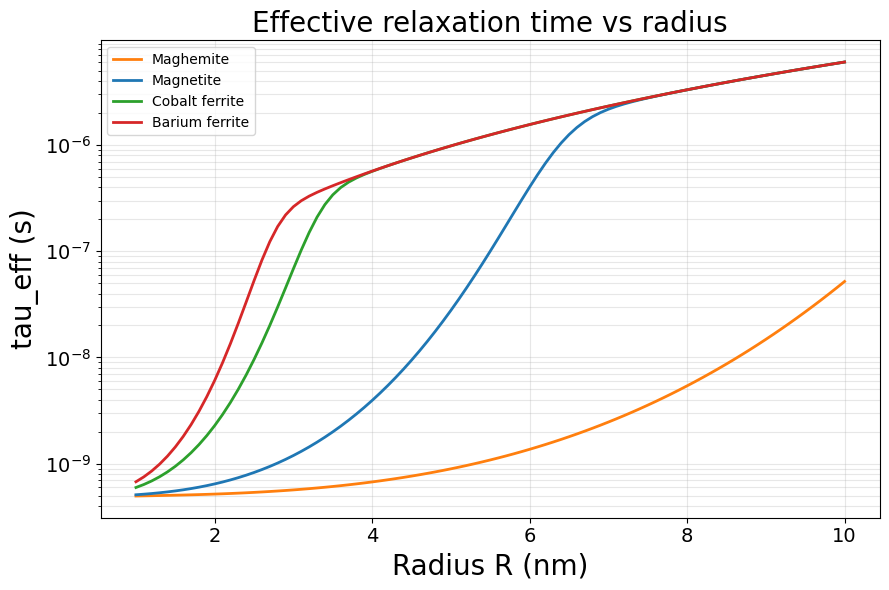

In [14]:
# ---------- build radius grid from input (E) ----------
R_nm, R = make_R(S1_R)                     # [nm], [m]

# ---------- volumes (same for every material) ----------
VM = (4/3) * np.pi * R**3                  # core volume        [m^3]
VH = (4/3) * np.pi * (R + delta)**3        # hydrodynamic volume [m^3]

# ---------- Brownian time (independent of K, Ms) ----------
tau_b = (3 * eta * VH) / (kB * T)          # [s]

# ---------- Neel + effective time, looped per material ----------
tau_eff_all = {}
for name in materials:
    K       = materials[name]['K']
    gamma   = (K * VM) / (kB * T)
    tau_n   = (tau0/2) * np.exp(np.minimum(gamma, 700))
    tau_eff = 1 / ((1/tau_b) + (1/tau_n))
    tau_eff_all[name] = tau_eff

# ---------- quick check at R = 6 nm ----------
i6 = np.argmin(np.abs(R_nm - 6.0))
print(f"At R = 6 nm:  VM = {VM[i6]:.3e} m^3,  tau_b = {tau_b[i6]:.3e} s")

# ---------- plot ----------
plt.figure(figsize=(9, 6))
for name in materials:
    plt.plot(R_nm, tau_eff_all[name], label=name, color=colors[name], linewidth=2)
plt.xlabel('Radius R (nm)', fontsize=20)
plt.ylabel('tau_eff (s)', fontsize=20)
plt.title('Effective relaxation time vs radius', fontsize=20)
plt.yscale('log')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 2) Imaginary susceptibility $\chi''$ vs frequency

Before finding the power released by the flipping magnetic moments, we must
first find the optimal frequency for each core radius. We build $\chi''$ from
two pieces:

$$\chi_0 = \frac{\mu_0 M_s^2 V_M}{3 k_B T}
\qquad
\chi'' = \frac{\chi_0\,\omega\tau_{\text{eff}}}{1 + (\omega\tau_{\text{eff}})^2}$$

$\chi_0$ is the static (equilibrium) susceptibility — it sets the overall height
and grows with the particle volume $V_M$. The second term gives the frequency
response: $\chi''$ is largest when $\omega\tau_{\text{eff}} = 1$, i.e. at
$f = \dfrac{1}{2\pi\tau_{\text{eff}}}$, and falls off on either side. So each
radius has its own optimal frequency through its $\tau_{\text{eff}}$. This cell
shows the maximum $\chi''$ at each radius of interest.

---

ก่อนที่เราจะไปหาพลังงานที่ออกมาจากการเปลี่ยนโมเมนต์แม่เหล็ก เราต้องหาความถี่ที่
เหมาะสมในแต่ละรัศมีของแกนแม่เหล็กก่อน โดย $\chi''$ สร้างขึ้นจากสองส่วน

$$\chi_0 = \frac{\mu_0 M_s^2 V_M}{3 k_B T}
\qquad
\chi'' = \frac{\chi_0\,\omega\tau_{\text{eff}}}{1 + (\omega\tau_{\text{eff}})^2}$$

$\chi_0$ คือ susceptibility สถิต (ที่สมดุล) เป็นตัวกำหนดความสูงโดยรวม และเพิ่มขึ้น
ตามปริมาตรอนุภาค $V_M$ ส่วนพจน์ที่สองคือการตอบสนองต่อความถี่ $\chi''$ จะมีค่ามาก
ที่สุดเมื่อ $\omega\tau_{\text{eff}} = 1$ นั่นคือที่ $f = \dfrac{1}{2\pi\tau_{\text{eff}}}$
และจะลดลงทั้งสองฝั่ง ดังนั้นแต่ละรัศมีจึงมีความถี่ที่เหมาะสมของตัวเองผ่านค่า
$\tau_{\text{eff}}$ เซลล์นี้จะแสดงให้เห็นถึง $\chi''$ สูงสุดในแต่ละรัศมีที่เราสนใจ

In [15]:
# ---------- frequency sweep + fine radius grid ----------
f     = np.logspace(F_LO_DEC, F_HI_DEC, N_F)   # [Hz]
omega = 2 * np.pi * f
R_nm, R_list = make_R(S2_R)                    # fine grid

# ---------- precompute chi''(f) and peak point for every material & R ----------
chi_dp_all   = {}   # chi''(f) full curve
f_peak_all   = {}   # peak frequency of each R
chi_peak_all = {}   # peak height of each R

for name in materials:
    Ms = materials[name]['Ms']
    K  = materials[name]['K']
    chi_dp_all[name], f_peak_all[name], chi_peak_all[name] = [], [], []

    for Rv in R_list:
        VM = (4/3) * np.pi * Rv**3
        VH = (4/3) * np.pi * (Rv + delta)**3

        tau_b   = (3 * eta * VH) / (kB * T)
        gamma   = (K * VM) / (kB * T)
        tau_n   = (tau0/2) * np.exp(np.minimum(gamma, 700))
        tau_eff = 1 / ((1/tau_b) + (1/tau_n))

        chi0   = (mu0 * Ms**2 * VM) / (3 * kB * T)
        chi_dp = (chi0 * omega * tau_eff) / (1 + (omega * tau_eff)**2)

        chi_dp_all[name].append(chi_dp)
        f_peak_all[name].append(1 / (2 * np.pi * tau_eff))   # analytic peak freq
        chi_peak_all[name].append(chi0 / 2)                  # analytic peak height


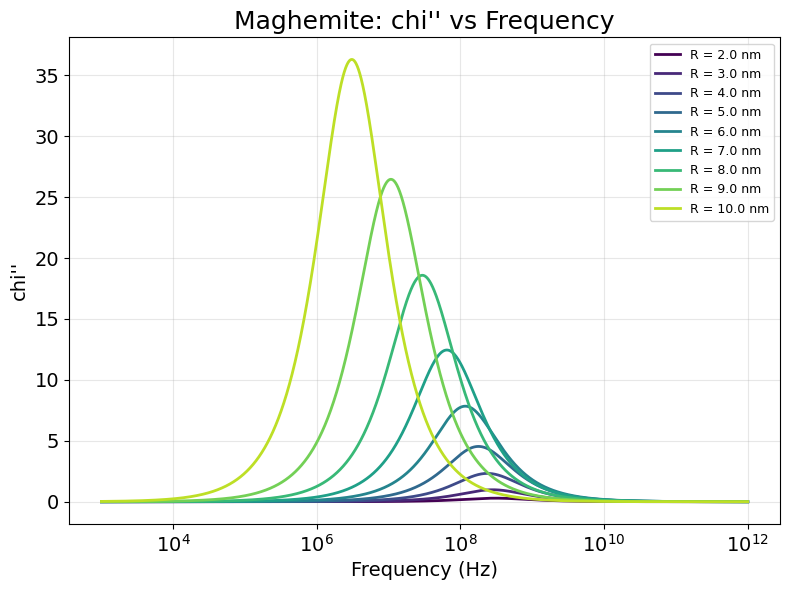

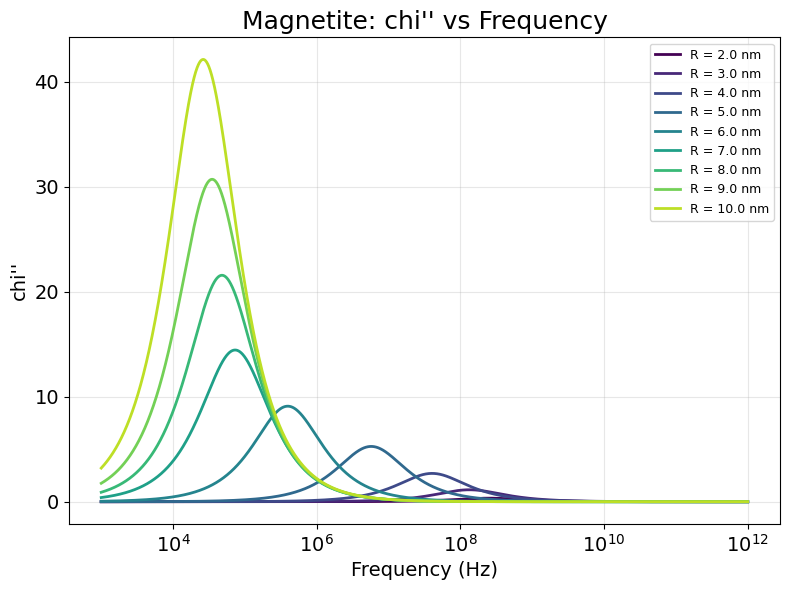

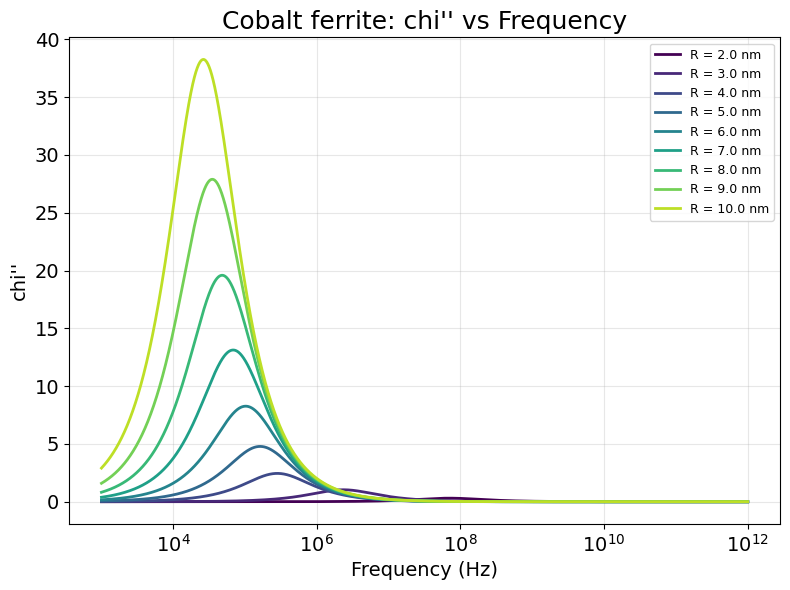

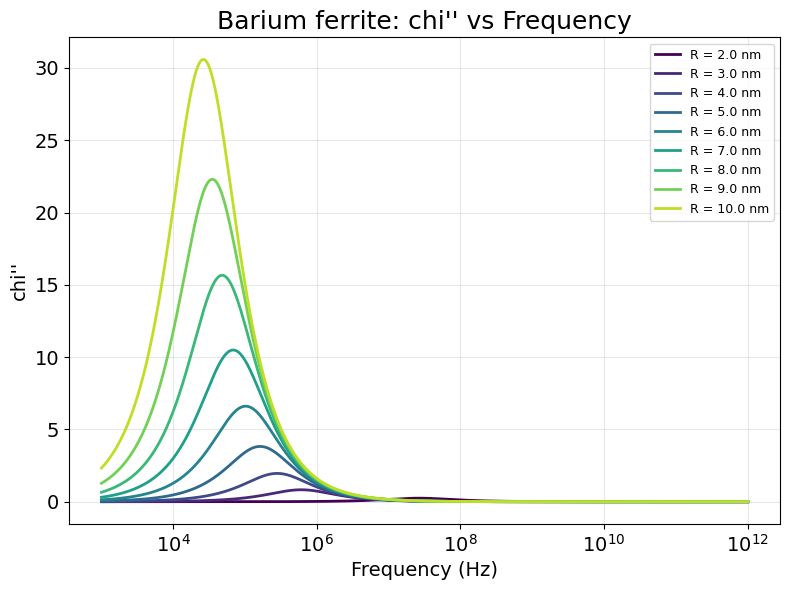

In [16]:
R_plot_nm = np.round(np.arange(S2_R_PLOT[0], S2_R_PLOT[2] + S2_R_PLOT[1]/2, S2_R_PLOT[1]), 2)
plot_idx = [np.argmin(np.abs(R_nm - rp)) for rp in R_plot_nm]
R_colors = plt.cm.viridis(np.linspace(0, 0.9, len(R_plot_nm)))

for name in materials:
    plt.figure(figsize=(8, 6))
    for j, idx in enumerate(plot_idx):
        plt.plot(f, chi_dp_all[name][idx], color=R_colors[j], linewidth=2,
                label=f'R = {R_nm[idx]:.1f} nm')
    plt.xscale('log')
    plt.title(f"{name}: chi'' vs Frequency", fontsize=18)
    plt.xlabel('Frequency (Hz)', fontsize=14)
    plt.ylabel("chi''", fontsize=14)
    plt.grid(True, which='both', alpha=0.3)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## 3) Peak analysis of chi''

From the previous section we already found `chi''_max` for each R. Next, for
every material over the range R ~ 0 to 30 nm, we focus on the **frequency**:
first, the **frequency** that produces `chi''_max` at each radius (this is the
optimal driving **frequency** for that particle size), and second, the value of
`chi''_max` reached at that **frequency**. The goal is to see how the optimal
**frequency** shifts as the radius grows.

---

จาก section ที่แล้วเราได้หา chi''_max ของแต่ละ R ไปแล้ว ต่อมาเราจะวิเคราะห์โดย
เน้นที่ **ความถี่** ในช่วงรัศมี ~0 ถึง 30 nm ของแต่ละวัสดุ อย่างแรกคือ **ความถี่**
ที่ทำให้เกิด chi''_max ในแต่ละรัศมี (คือ **ความถี่** ที่เหมาะสมที่สุดสำหรับอนุภาค
ขนาดนั้น) และอย่างที่สองคือค่า chi''_max ที่ได้ ณ **ความถี่** นั้น เป้าหมายคือดูว่า
**ความถี่** ที่เหมาะสมเลื่อนไปอย่างไรเมื่อรัศมีเพิ่มขึ้น

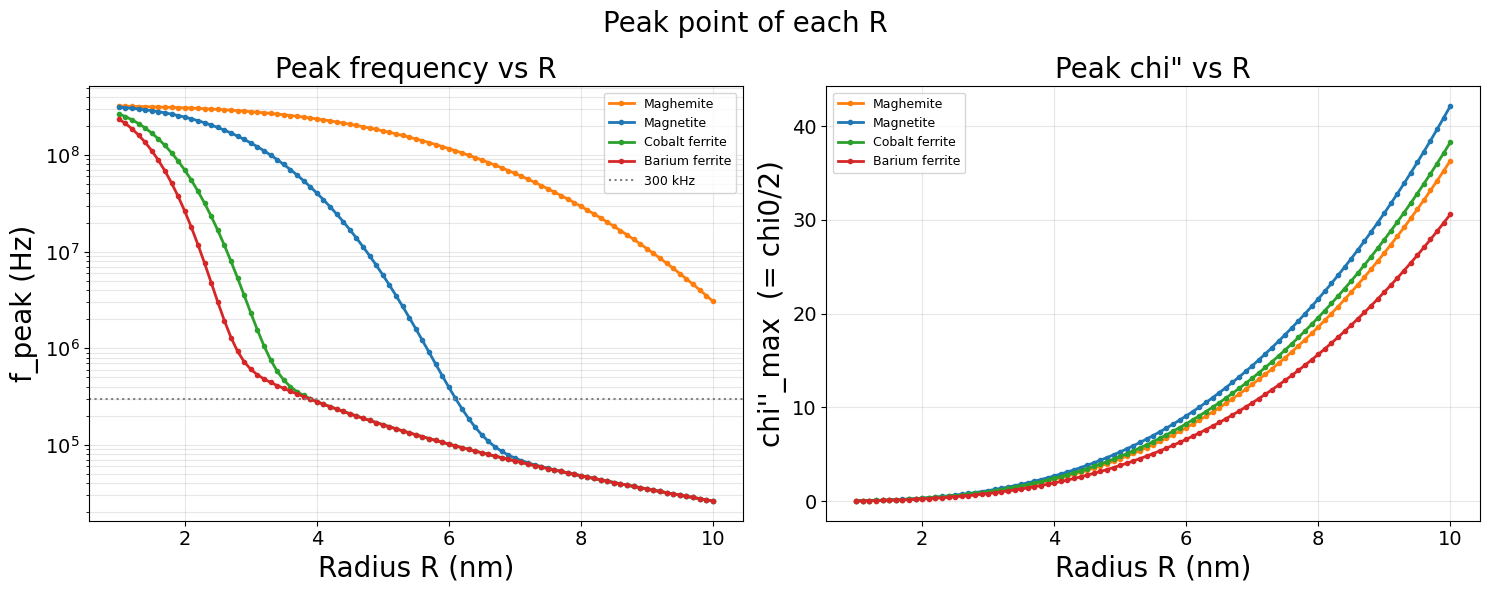

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# left: peak frequency vs R
for name in materials:
    ax1.plot(R_nm, f_peak_all[name], color=colors[name], linewidth=2,
             marker='o', markersize=3, label=name)
ax1.axhline(300e3, color='gray', linestyle=':', label='300 kHz')
ax1.set_xlabel('Radius R (nm)')
ax1.set_ylabel('f_peak (Hz)')
ax1.set_yscale('log')
ax1.set_title('Peak frequency vs R')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend(fontsize=9)

# right: peak height vs R  (= chi0/2)
for name in materials:
    ax2.plot(R_nm, chi_peak_all[name], color=colors[name], linewidth=2,
             marker='o', markersize=3, label=name)
ax2.set_xlabel('Radius R (nm)')
ax2.set_ylabel("chi''_max  (= chi0/2)")
ax2.set_title('Peak chi" vs R')
ax2.grid(True, which='both', alpha=0.3)
ax2.legend(fontsize=9)

plt.suptitle('Peak point of each R', fontsize=20)
plt.tight_layout()
plt.show()


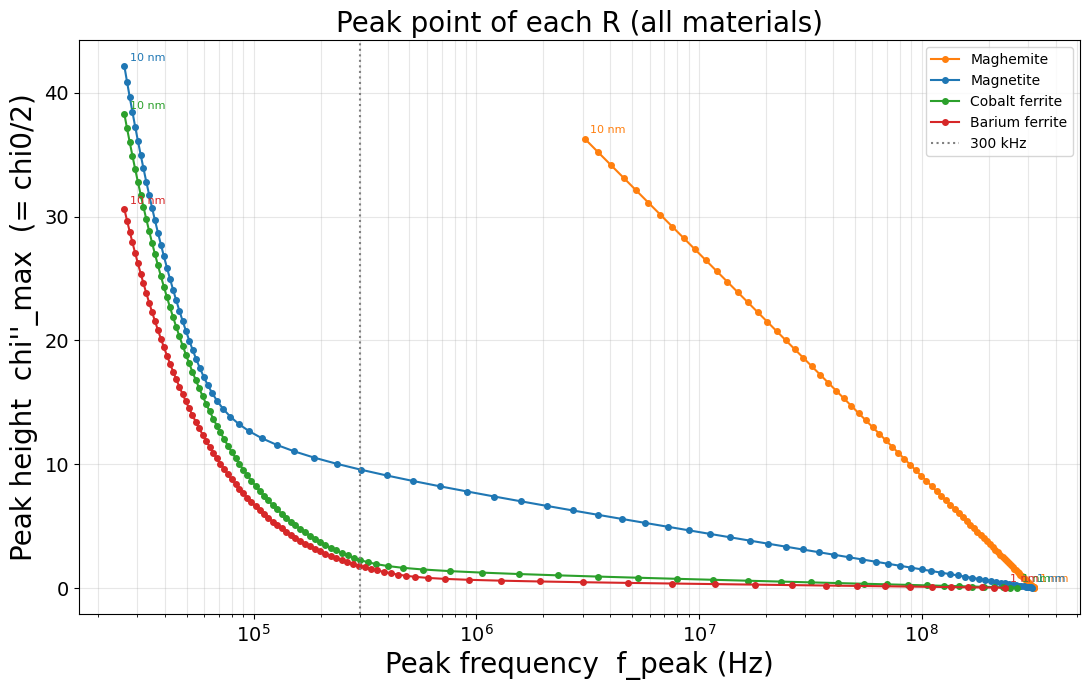

In [18]:
# peak locus: peak height vs peak frequency, tracing R for each material
plt.figure(figsize=(11, 7))
for name in materials:
    fp = np.array(f_peak_all[name])
    cp = np.array(chi_peak_all[name])
    plt.plot(fp, cp, color=colors[name], linewidth=1.5, marker='o', markersize=4, label=name)
    # label the two endpoints so the direction of increasing R is clear
    plt.annotate(f'{R_nm[0]:.0f} nm',  (fp[0],  cp[0]),  fontsize=8,
                 color=colors[name], xytext=(4, 4), textcoords='offset points')
    plt.annotate(f'{R_nm[-1]:.0f} nm', (fp[-1], cp[-1]), fontsize=8,
                 color=colors[name], xytext=(4, 4), textcoords='offset points')

plt.axvline(300e3, color='gray', linestyle=':', label='300 kHz')
plt.xscale('log')
plt.xlabel('Peak frequency  f_peak (Hz)', fontsize=20)
plt.ylabel("Peak height  chi''_max  (= chi0/2)", fontsize=20)
plt.title('Peak point of each R (all materials)', fontsize=20)
plt.grid(True, which='both', alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


## 4) Power dissipation P vs frequency — corner point (analytic)

For the material `PF_MAT` and each radius in `PF_R`, we plot `P(f)`. Note that
`P(f)` has **no interior peak** — it rises and saturates to a plateau. The marked
corner point is the analytic `f_best = 1/(2 pi tau_eff)` (where chi'' peaks);
there `P` equals exactly half of its high-frequency plateau.

In this section we are **not** yet hunting for the overall maximum. The point is
simply to show that even when each radius is driven at its own optimal frequency,
that radius may still **not** deliver the highest power the material is capable
of. In the power expression


$$P_{\text{best}} = \mu_0\, H_{\text{app}}^2\, f_{\text{best}}\, \pi\, \chi_{\text{best}}$$


the frequency carries more weight in setting the output power, so a high chi''
does not necessarily give a proportionally high power. Reaching the highest chi''
is therefore not enough on its own — the best result needs the right *pairing* of
radius and frequency, which we search for in Section 5.

---

สำหรับวัสดุ `PF_MAT` และแต่ละรัศมีใน `PF_R` เราพล็อต `P(f)` สังเกตว่า `P(f)` ไม่มี
ยอด (peak) ตรงกลาง — มันไต่ขึ้นแล้วอิ่มตัวเป็น plateau จุด corner ที่มาร์กไว้คือค่า
analytic `f_best = 1/(2 pi tau_eff)` (ที่ chi'' พีค) ซึ่งตรงนั้น `P` มีค่าเท่ากับ
ครึ่งหนึ่งของ plateau พอดี

ในส่วนที่ 4 นี้เรายัง **ไม่** ได้หาจุดยอดสูงสุด แต่แค่ต้องการแสดงให้เห็นว่า ถึงแต่ละรัศมี
จะใช้ความถี่ที่เหมาะสมของตัวเองแล้ว รัศมีนั้นก็อาจ **ยังไม่** ให้พลังงานสูงสุดที่วัสดุชนิด
นั้นทำได้ ในสมการพลังงาน


$$P_{\text{best}} = \mu_0\, H_{\text{app}}^2\, f_{\text{best}}\, \pi\, \chi_{\text{best}}$$


ความถี่จะมีน้ำหนักในการกำหนดพลังงานที่ออกมามากกว่า ดังนั้นถึงจะมีค่า chi'' ที่สูง ก็ไม่
ได้ให้พลังงานสูงตามไปด้วยเสมอ การได้ chi'' สูงสุดเพียงอย่างเดียวจึงไม่พอ — ผลลัพธ์ที่ดี
ที่สุดต้องอาศัยการ**จับคู่**รัศมีกับความถี่ให้เหมาะสม ซึ่งเราจะไปหาใน Section 5

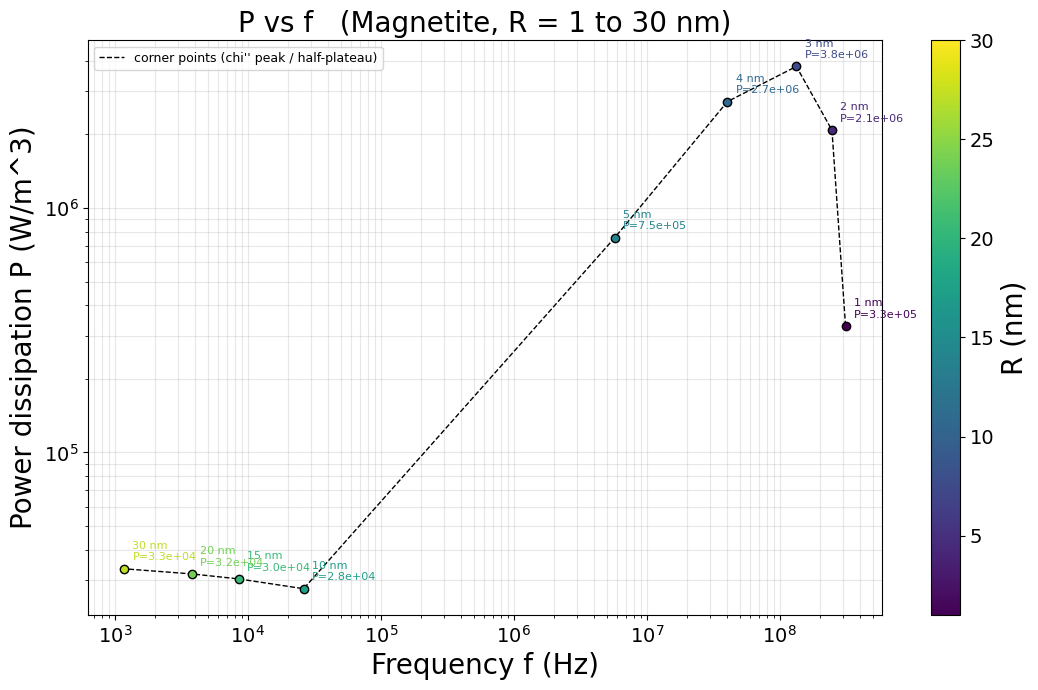

Material: Magnetite

 R (nm)    f_best (Hz)    P at f_best      P plateau
    1.0      3.125e+08      3.292e+05      6.584e+05
    2.0      2.470e+08      2.081e+06      4.163e+06
    3.0      1.334e+08      3.794e+06      7.588e+06
    4.0      4.040e+07      2.723e+06      5.447e+06
    5.0      5.734e+06      7.550e+05      1.510e+06
   10.0      2.628e+04      2.768e+04      5.535e+04
   15.0      8.538e+03      3.035e+04      6.070e+04
   20.0      3.776e+03      3.182e+04      6.364e+04
   30.0      1.174e+03      3.339e+04      6.677e+04


In [19]:
Mat = PF_MAT
Ms  = materials[Mat]['Ms']; K = materials[Mat]['K']
Cp  = materials[Mat]['Cp']; rho = materials[Mat]['rho']

R_nm = np.array([1,2,3,4,5,10,15,20,30], dtype=float)
f_grid  = np.logspace(F_LO_DEC, F_HI_DEC, 1000)
omega   = 2 * np.pi * f_grid
R_colors = plt.cm.viridis(np.linspace(0, 0.9, len(R_nm)))

# ---------- per R: P(f) curve + analytic corner point + plateau ----------
P_all, f_best_all, P_best_all, P_plat_all = {}, {}, {}, {}
for Rv_nm in R_nm:
    R_m = Rv_nm * 1e-9
    VM = (4/3) * np.pi * R_m**3
    VH = (4/3) * np.pi * (R_m + delta)**3

    tau_b   = (3 * eta * VH) / (kB * T)
    gamma   = (K * VM) / (kB * T)
    tau_n   = (tau0/2) * np.exp(np.minimum(gamma, 700))
    tau_eff = 1 / ((1/tau_b) + (1/tau_n))

    chi0   = (mu0 * Ms**2 * VM) / (3 * kB * T)
    chi_dp = (chi0 * omega * tau_eff) / (1 + (omega * tau_eff)**2)
    P      = mu0 * H_app**2 * f_grid * np.pi * chi_dp
    P_all[Rv_nm] = P

    f_best   = 1 / (2 * np.pi * tau_eff)
    w_best   = 2 * np.pi * f_best
    chi_best = (chi0 * w_best * tau_eff) / (1 + (w_best * tau_eff)**2)   # = chi0/2
    P_best   = mu0 * H_app**2 * f_best * np.pi * chi_best
    f_best_all[Rv_nm] = f_best
    P_best_all[Rv_nm] = P_best
    P_plat_all[Rv_nm] = 2 * P_best     # plateau

# ---------- plot ----------
plt.figure(figsize=(11, 7))
for c, Rv_nm in zip(R_colors, R_nm):
    # Removed: plt.plot(f_grid, P_all[Rv_nm], color=c, linewidth=1.5)
    fb, pb = f_best_all[Rv_nm], P_best_all[Rv_nm]
    plt.plot(fb, pb, 'o', color=c, markersize=6, markeredgecolor='black', zorder=5)
    if len(R_nm) <= 12: # Add annotation only if there are a manageable number of points
        plt.annotate(f'{Rv_nm:.0f} nm\nP={pb:.1e}', (fb, pb),
                     textcoords='offset points', xytext=(6, 6), fontsize=8, color=c)
plt.plot(list(f_best_all.values()), list(P_best_all.values()),
         'k--', linewidth=1, label="corner points (chi'' peak / half-plateau)")
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Frequency f (Hz)', fontsize=20)
plt.ylabel('Power dissipation P (W/m^3)', fontsize=20)
plt.title(f'P vs f   ({Mat}, R = {R_nm[0]:.0f} to {R_nm[-1]:.0f} nm)', fontsize=20)
plt.grid(True, which='both', alpha=0.3)
sm = ScalarMappable(norm=Normalize(vmin=R_nm.min(), vmax=R_nm.max()), cmap='viridis'); sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label='R (nm)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ---------- table ----------
print(f"Material: {Mat}\n")
print(f"{'R (nm)':>7s} {'f_best (Hz)':>14s} {'P at f_best':>14s} {'P plateau':>14s}")
for Rv_nm in R_nm:
    print(f"{Rv_nm:7.1f} {f_best_all[Rv_nm]:14.3e} {P_best_all[Rv_nm]:14.3e} {P_plat_all[Rv_nm]:14.3e}")

## 5) Power dissipation P vs frequency — f_best found by sweeping

To find the radius and frequency that deliver the highest power over
R = 0 to 30 nm, we use the same idea as Section 4 but with finer resolution over
the radius range of interest. The maximum power this material can provide through
Magnetic Hyperthermia (LRT) should come from the radius that yields the greatest
power — each evaluated at the frequency matched to that radius.

---

การที่เราจะหารัศมีและความถี่ที่ให้พลังงานสูงที่สุดในช่วงรัศมี 0-30 nm เราจะใช้แนวคิด
เดียวกับ Section 4 แต่เพิ่มความละเอียดในช่วงรัศมีที่น่าสนใจ ซึ่งพลังงานที่วัสดุชนิดนี้
สามารถให้ได้สูงสุดจาก Magnetic Hyperthermia (LRT) ควรจะเป็นรัศมีที่ให้พลังงานได้
สูงที่สุด โดยใช้ความถี่ที่เหมาะสมกับรัศมีนั้นด้วย

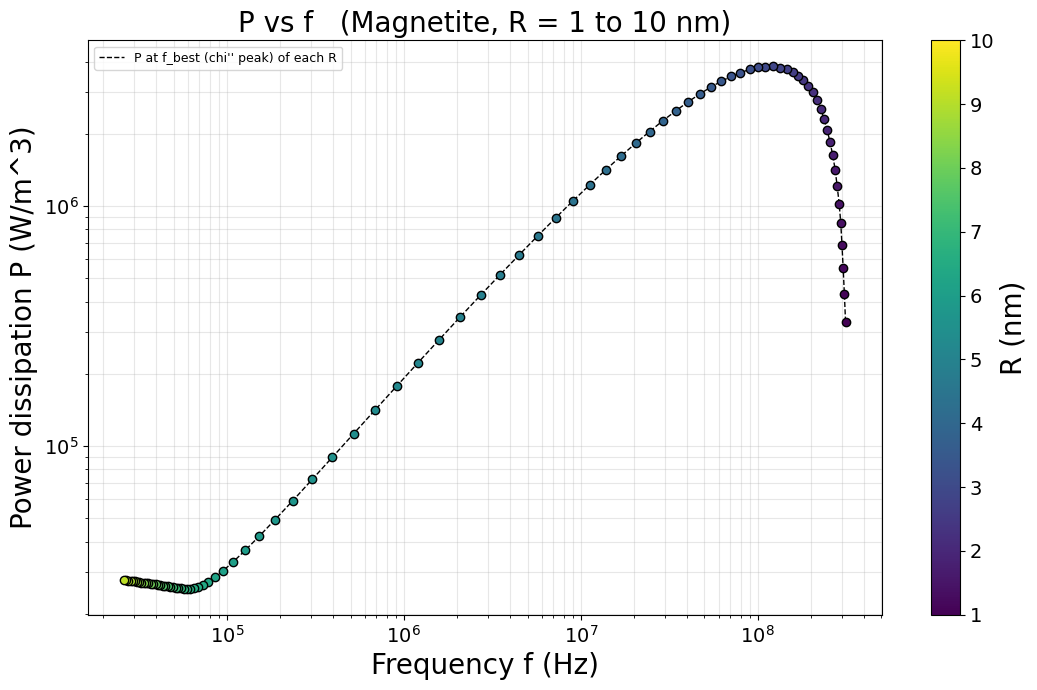


MAX P at f_best:
  R      = 3.1 nm
  f_best = 1.220e+08 Hz
  P      = 3.827e+06 W/m^3


In [20]:
Mat = PF_MAT
Ms  = materials[Mat]['Ms']; K = materials[Mat]['K']
Cp  = materials[Mat]['Cp']; rho = materials[Mat]['rho']

R_nm, _ = make_R(PF_R)
f_grid  = np.logspace(F_LO_DEC, F_HI_DEC, N_F)   # swept
omega   = 2 * np.pi * f_grid
R_colors = plt.cm.viridis(np.linspace(0, 0.9, len(R_nm)))

# ---------- per R: sweep f, find f_best = argmax(chi''), record P there ----------
P_all, f_best_all, P_best_all = {}, {}, {}
for Rv_nm in R_nm:
    R_m = Rv_nm * 1e-9
    VM = (4/3) * np.pi * R_m**3
    VH = (4/3) * np.pi * (R_m + delta)**3

    tau_b   = (3 * eta * VH) / (kB * T)
    gamma   = (K * VM) / (kB * T)
    tau_n   = (tau0/2) * np.exp(np.minimum(gamma, 700))
    tau_eff = 1 / ((1/tau_b) + (1/tau_n))

    chi0   = (mu0 * Ms**2 * VM) / (3 * kB * T)
    chi_dp = (chi0 * omega * tau_eff) / (1 + (omega * tau_eff)**2)
    P      = mu0 * H_app**2 * f_grid * np.pi * chi_dp
    P_all[Rv_nm] = P

    i_best = np.argmax(chi_dp)              # sweep -> peak of chi''
    f_best_all[Rv_nm] = f_grid[i_best]
    P_best_all[Rv_nm] = P[i_best]

# ---------- plot ----------
plt.figure(figsize=(11, 7))
for c, Rv_nm in zip(R_colors, R_nm):
    # Removed: plt.plot(f_grid, P_all[Rv_nm], color=c, linewidth=1.5)
    fb, pb = f_best_all[Rv_nm], P_best_all[Rv_nm]
    plt.plot(fb, pb, 'o', color=c, markersize=6, markeredgecolor='black', zorder=5)
    if len(R_nm) <= 12:
        plt.annotate(f'{Rv_nm:.0f} nm\nP={pb:.1e}', (fb, pb),
                     textcoords='offset points', xytext=(6, 6), fontsize=8, color=c)
plt.plot(list(f_best_all.values()), list(P_best_all.values()),
         'k--', linewidth=1, label="P at f_best (chi'' peak) of each R")
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Frequency f (Hz)', fontsize=20)
plt.ylabel('Power dissipation P (W/m^3)', fontsize=20)
plt.title(f'P vs f   ({Mat}, R = {R_nm[0]:.0f} to {R_nm[-1]:.0f} nm)', fontsize=20)
plt.grid(True, which='both', alpha=0.3)
sm = ScalarMappable(norm=Normalize(vmin=R_nm.min(), vmax=R_nm.max()), cmap='viridis'); sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label='R (nm)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ---------- find the R with the largest "P at f_best" ----------
R_max = max(P_best_all, key=P_best_all.get)     # R (nm) that maximizes P at f_best
print(f"\nMAX P at f_best:")
print(f"  R      = {R_max:.1f} nm")
print(f"  f_best = {f_best_all[R_max]:.3e} Hz")
print(f"  P      = {P_best_all[R_max]:.3e} W/m^3")

## 6) Validity check — Langevin parameter $\xi \leq 1$

Everything above assumes **Linear Response Theory (LRT)**, which only holds when
the magnetic energy is small compared to thermal energy. This is measured by the
dimensionless **Langevin parameter**

$$\xi = \frac{\mu_0 M_s V_M H_{\text{app}}}{k_B T},
\qquad V_M = \tfrac{4}{3}\pi R^3 .$$

LRT is valid while $\xi \leq 1$. Since $V_M \propto R^3$, $\xi$ grows quickly with
radius, so large particles eventually break the assumption. This cell plots
$\xi(R)$ for every material, marks the $\xi = 1$ line, and reports the radius
where each material crosses it — telling us how far out the earlier results can
be trusted.

---

ทุกอย่างข้างบนตั้งอยู่บนสมมติฐาน **Linear Response Theory (LRT)** ซึ่งใช้ได้ก็ต่อ
เมื่อพลังงานแม่เหล็กมีค่าน้อยเมื่อเทียบกับพลังงานความร้อน วัดได้ด้วย **Langevin
parameter** ที่ไม่มีหน่วย

$$\xi = \frac{\mu_0 M_s V_M H_{\text{app}}}{k_B T},
\qquad V_M = \tfrac{4}{3}\pi R^3 .$$

LRT ใช้ได้เมื่อ $\xi \leq 1$ เนื่องจาก $V_M \propto R^3$ ค่า $\xi$ จึงโตเร็วมากตาม
รัศมี ทำให้อนุภาคขนาดใหญ่หลุดจากสมมติฐานในที่สุด เซลล์นี้พล็อต $\xi(R)$ ของทุกวัสดุ
มาร์กเส้น $\xi = 1$ และรายงานรัศมีที่แต่ละวัสดุข้ามเส้นนั้น เพื่อบอกว่าผลลัพธ์ก่อนหน้า
เชื่อถือได้ถึงรัศมีเท่าไร

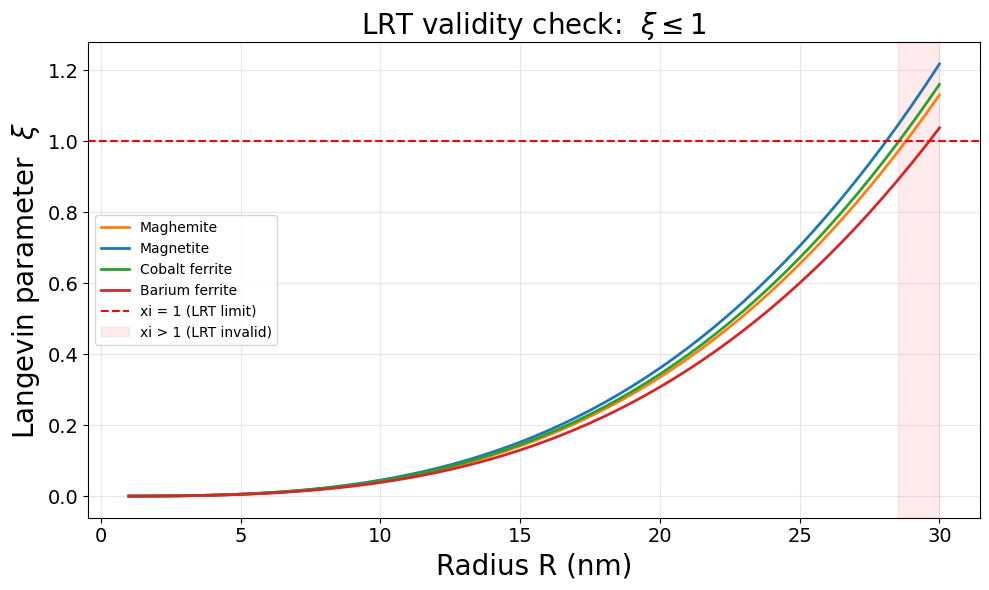

Applied field H_app = 0.100 mT

Material          xi at 10nm  xi at 30nm   R where xi=1
Maghemite              0.042       1.130        29.0 nm
Magnetite              0.045       1.218        28.5 nm
Cobalt ferrite         0.043       1.160        29.0 nm
Barium ferrite         0.038       1.038        30.0 nm

Radius ranges used above:
  S2_R (chi & peaks)     up to 10.0 nm -> max xi = 0.045  OK (xi <= 1)
  PF_R (P vs f)          up to 10.0 nm -> max xi = 0.045  OK (xi <= 1)


In [21]:
# ---------- radius grid for the validity check (1 .. 30 nm) ----------
R_nm, R = make_R((1.0, 0.5, 30.0))              # [nm], [m]

# ---------- Langevin parameter xi(R) for each material ----------
# xi = mu0 * Ms * VM * H_app / (kB*T), with VM the magnetic CORE volume
VM = (4/3) * np.pi * R**3
xi_all = {}
for name in materials:
    Ms = materials[name]['Ms']
    xi_all[name] = (mu0 * Ms * VM * H_app) / (kB * T)

# ---------- plot xi vs R ----------
plt.figure(figsize=(10, 6))
for name in materials:
    plt.plot(R_nm, xi_all[name], color=colors[name], linewidth=2, label=name)

plt.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='xi = 1 (LRT limit)')
# shade the region where any material has xi > 1
xi_stack = np.vstack([xi_all[name] for name in materials])
if np.any(xi_stack > 1):
    R_break = R_nm[np.argmax(xi_stack.max(axis=0) > 1)]
    plt.axvspan(R_break, R_nm.max(), color='red', alpha=0.08, label='xi > 1 (LRT invalid)')

plt.xlabel('Radius R (nm)', fontsize=20)
plt.ylabel(r'Langevin parameter  $\xi$', fontsize=20)
plt.title(r'LRT validity check:  $\xi \leq 1$', fontsize=20)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ---------- report the crossing radius for each material ----------
print(f"Applied field H_app = {H_app_T*1e3:.3f} mT\n")
print(f"{'Material':16s} {'xi at 10nm':>11s} {'xi at 30nm':>11s} {'R where xi=1':>14s}")
for name in materials:
    xi = xi_all[name]
    i10 = np.argmin(np.abs(R_nm - 10.0))
    i30 = np.argmin(np.abs(R_nm - 30.0))
    over = np.where(xi > 1)[0]
    R_cross = f"{R_nm[over[0]]:.1f} nm" if len(over) else "> 30 nm (OK)"
    print(f"{name:16s} {xi[i10]:11.3f} {xi[i30]:11.3f} {R_cross:>14s}")

# ---------- verdict for the ranges actually used in this notebook ----------
print("\nRadius ranges used above:")
for tag, t in [('S2_R (chi'' & peaks)', S2_R), ('PF_R (P vs f)', PF_R)]:
    R_end_nm = t[2]
    worst = max((mu0 * materials[n]['Ms'] * (4/3)*np.pi*(R_end_nm*1e-9)**3 * H_app) / (kB*T)
                for n in materials)
    status = "OK (xi <= 1)" if worst <= 1 else "!! xi > 1 at the top of the range"
    print(f"  {tag:22s} up to {R_end_nm:.1f} nm -> max xi = {worst:.3f}  {status}")


## 8) SAR and Heating rate at the best operating point

Section 5 found, for material `PF_MAT`, the radius that delivers the most power
together with its matched frequency — call them $R_{\text{best}}$ and
$f_{\text{best}}$ (the pair that maximizes $P$ at each radius's $\chi''$ peak).
Here we convert that peak power into the two quantities used to judge a
hyperthermia agent:

$$\text{SAR} = \frac{P}{\rho}\ \left[\frac{\text{W}}{\text{kg}}\right],
\qquad
\frac{dT}{dt} = \frac{P}{\rho\, c}\ \left[\frac{\text{K}}{\text{s}}\right].$$

Both are just the power $P$ rescaled by the material density $\rho$ (and heat
capacity $c$), so their curves have the same shape as $P(f)$. We plot SAR and
heating rate versus frequency for every radius, mark the best point
$(R_{\text{best}}, f_{\text{best}})$ on each, and report the final numbers there.

---

Section 5 ได้หารัศมีที่ให้พลังงานสูงสุดของวัสดุ `PF_MAT` พร้อมความถี่ที่จับคู่กัน —
เรียกว่า $R_{\text{best}}$ และ $f_{\text{best}}$ (คู่ที่ทำให้ $P$ สูงสุด ณ จุด $\chi''$
พีคของแต่ละรัศมี) ในเซลล์นี้เราจะแปลงพลังงานสูงสุดนั้นเป็นสองปริมาณที่ใช้ตัดสิน
ตัวแทนทำ hyperthermia

$$\text{SAR} = \frac{P}{\rho}\ \left[\frac{\text{W}}{\text{kg}}\right],
\qquad
\frac{dT}{dt} = \frac{P}{\rho\, c}\ \left[\frac{\text{K}}{\text{s}}\right].$$

ทั้งคู่คือพลังงาน $P$ ที่หารด้วยความหนาแน่น $\rho$ (และความจุความร้อน $c$) รูปกราฟ
จึงเหมือน $P(f)$ ทุกประการ เราพล็อต SAR และ heating rate เทียบกับความถี่ของทุก
รัศมี มาร์กจุดที่ดีที่สุด $(R_{\text{best}}, f_{\text{best}})$ บนแต่ละกราฟ และรายงาน
ค่าสุดท้าย ณ จุดนั้น

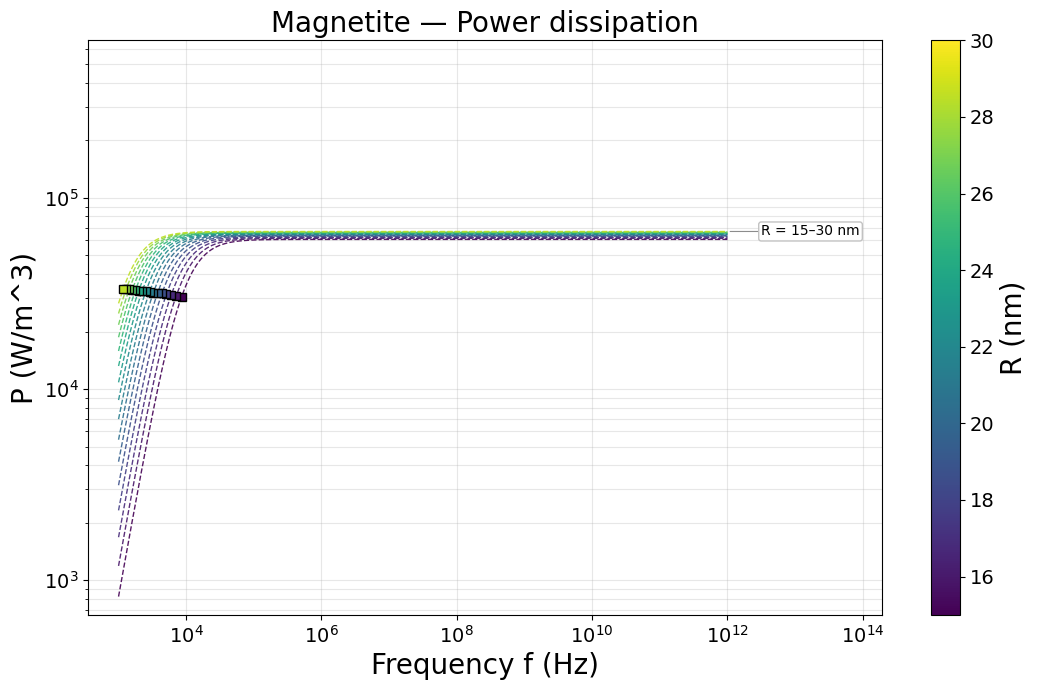

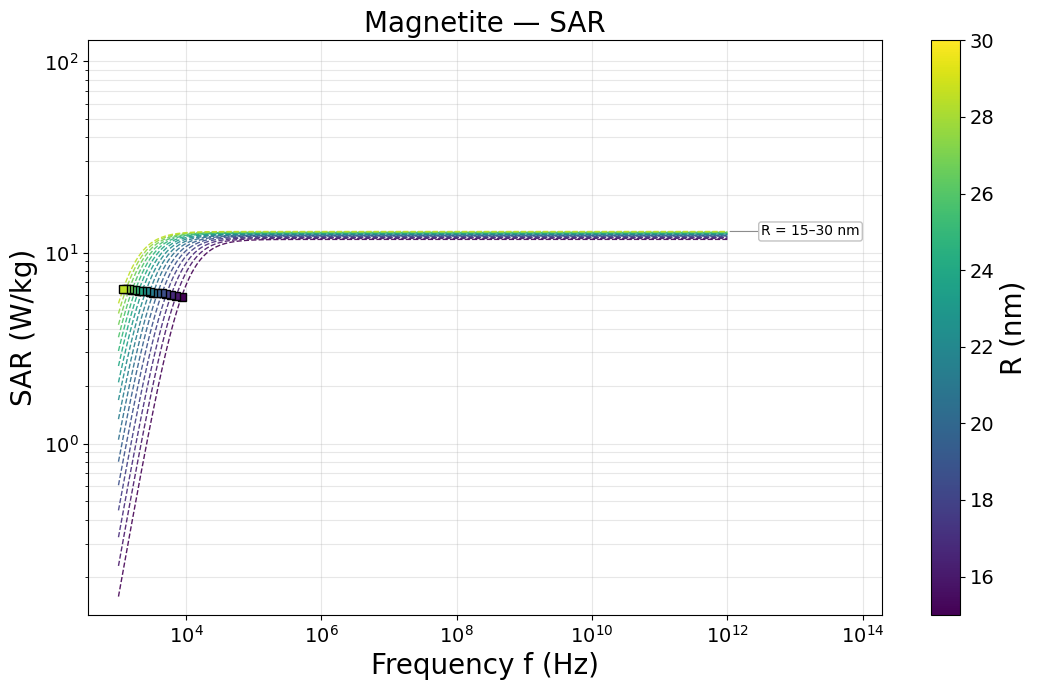

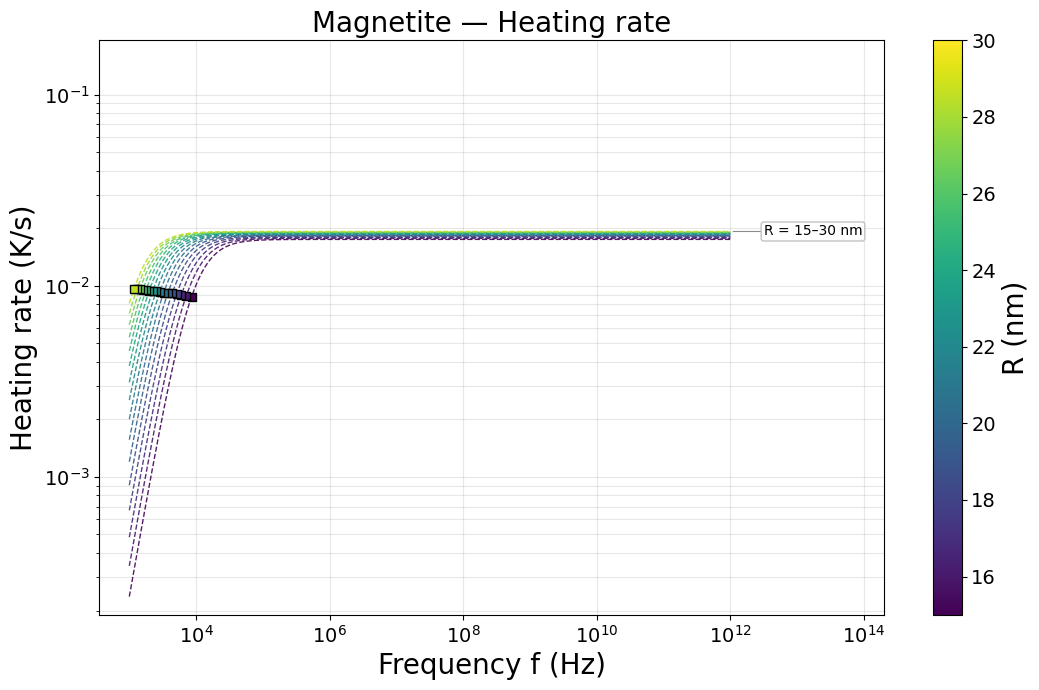


Material: Magnetite - Summary at each R's own f_best
 R (nm)    f_best (Hz)     SAR (W/kg)     Heat (K/s)
   15.0      8.545e+03      5.864e+00      8.753e-03
   16.0      7.128e+03      5.937e+00      8.861e-03
   17.0      6.008e+03      6.002e+00      8.958e-03
   18.0      5.090e+03      6.036e+00      9.008e-03
   19.0      4.379e+03      6.108e+00      9.116e-03
   20.0      3.768e+03      6.130e+00      9.149e-03
   21.0      3.276e+03      6.170e+00      9.208e-03
   22.0      2.878e+03      6.232e+00      9.301e-03
   23.0      2.528e+03      6.255e+00      9.336e-03
   24.0      2.233e+03      6.276e+00      9.367e-03
   25.0      1.992e+03      6.329e+00      9.447e-03
   26.0      1.778e+03      6.353e+00      9.482e-03
   27.0      1.594e+03      6.381e+00      9.523e-03
   28.0      1.437e+03      6.416e+00      9.575e-03
   29.0      1.296e+03      6.426e+00      9.591e-03
   30.0      1.174e+03      6.447e+00      9.622e-03


In [22]:
# ---------- read inputs ----------
Mat = PF_MAT
Ms  = materials[Mat]['Ms']; K = materials[Mat]['K']
Cp  = materials[Mat]['Cp']; rho = materials[Mat]['rho']

# radii of interest (nm) — edited in the INPUT cell (G): PF_R_INTEREST
R_interest = np.array(PF_R_INTEREST, dtype=float)

f_grid = np.logspace(F_LO_DEC, F_HI_DEC, N_F)   # frequency sweep
omega  = 2 * np.pi * f_grid

# ---------- per R of interest: sweep f, take that R's own f_best = argmax(chi''), record P/SAR/heat there ----------
P_all, SAR_all, HEAT_all = {}, {}, {}
f_best_all, P_best_all, SAR_best_all, heat_best_all = {}, {}, {}, {}

for Rv_nm in R_interest:
    R_m = Rv_nm * 1e-9
    VM = (4/3) * np.pi * R_m**3
    VH = (4/3) * np.pi * (R_m + delta)**3

    tau_b   = (3 * eta * VH) / (kB * T)
    gamma   = (K * VM) / (kB * T)
    tau_n   = (tau0/2) * np.exp(np.minimum(gamma, 700))
    tau_eff = 1 / ((1/tau_b) + (1/tau_n))

    chi0   = (mu0 * Ms**2 * VM) / (3 * kB * T)
    chi_dp = (chi0 * omega * tau_eff) / (1 + (omega * tau_eff)**2)
    P      = mu0 * H_app**2 * f_grid * np.pi * chi_dp
    P_all[Rv_nm]    = P                    # [W/m^3]
    SAR_all[Rv_nm]  = P / rho              # [W/kg]
    HEAT_all[Rv_nm] = P / (rho * Cp)       # [K/s]

    i_best = np.argmax(chi_dp)             # f_best = chi'' peak of THIS R (its matched frequency)
    f_best_all[Rv_nm]    = f_grid[i_best]
    P_best_all[Rv_nm]    = P[i_best]
    SAR_best_all[Rv_nm]  = SAR_all[Rv_nm][i_best]
    heat_best_all[Rv_nm] = HEAT_all[Rv_nm][i_best]

# Use viridis colormap to match Section 4
extra_colors = plt.cm.viridis(np.linspace(0, 0.9, len(R_interest)))

# ---------- group adjacent markers that sit close together on the log-log plane ----------
# singles get their own "R = x nm" label; a tight cluster gets one "R = a-b nm" range label
def cluster_points(x, y, thresh=0.35):
    lx, ly = np.log10(x), np.log10(y)
    groups = [[0]]
    for i in range(1, len(x)):
        d = np.hypot(lx[i] - lx[i-1], ly[i] - ly[i-1])
        groups[-1].append(i) if d < thresh else groups.append([i])
    return groups

# ---------- labels at the RIGHT END of each curve, stacked as a tidy right-side column ----------
# each label is tied by a thin leader that attaches to the LEFT edge of its box; spacing is
# pixel-accurate so boxes never touch. Call this AFTER colorbar + tight_layout (axes size is final).
def place_labels_right(ax, x_end, items, fontsize=10, dx_dec=0.5, pad=1.7):
    fig = ax.figure; fig.canvas.draw()
    axb = ax.get_window_extent(); axes_px_h, axes_px_w = axb.height, axb.width
    tmp = ax.annotate('R = 00\u201300 nm', (x_end, items[0][0]), fontsize=fontsize,
                      bbox=dict(boxstyle='round,pad=0.18'))
    fig.canvas.draw()
    th = tmp.get_bbox_patch().get_window_extent().height     # full label-box height (px)
    tw = tmp.get_bbox_patch().get_window_extent().width      # full label-box width  (px)
    tmp.remove()
    bottom_log = np.log10(ax.get_ylim()[0]); left_log = np.log10(ax.get_xlim()[0])
    order = sorted(range(len(items)), key=lambda k: items[k][0])
    true_logs = [np.log10(items[k][0]) for k in order]
    # grow the top so the pixel gap between stacked boxes is >= th*pad, then push overlaps up
    top_log = max(true_logs) + 1.0
    for _ in range(30):
        span = top_log - bottom_log
        gap = th * pad / axes_px_h * span
        adj = list(true_logs)
        for i in range(1, len(adj)):
            if adj[i] < adj[i-1] + gap:
                adj[i] = adj[i-1] + gap
        need = adj[-1] + gap * 0.6
        if need <= top_log + 1e-9:
            break
        top_log = need
    ax.set_ylim(top=10**top_log)
    lx = np.log10(x_end) + dx_dec                            # label column sits to the right of the line ends
    a = tw / axes_px_w                                       # widen x so the column fits inside
    ax.set_xlim(right=10**((lx + 0.25 - a*left_log) / (1 - a)))
    for pos, k in enumerate(order):
        ax.annotate(items[k][1], xy=(x_end, items[k][0]), xytext=(10**lx, 10**adj[pos]),
                    textcoords='data', ha='left', va='center', fontsize=fontsize,
                    color='black', zorder=7,
                    bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='0.75', alpha=0.95),
                    arrowprops=dict(arrowstyle='-', color='0.55', lw=0.8, shrinkA=0, shrinkB=2,
                                    relpos=(0, 0.5)))        # leader attaches to the LEFT edge of the box

# ---------- one separate figure per quantity ----------
panels = [
    ('Power dissipation', 'P (W/m^3)',      P_all,    P_best_all,    'power_dissipation'),
    ('SAR',               'SAR (W/kg)',     SAR_all,  SAR_best_all,  'sar'),
    ('Heating rate',      'Heating rate (K/s)', HEAT_all, heat_best_all, 'heating_rate'),
]

for title, ylab, curve_all, best_vals, fname in panels:
    fig, ax = plt.subplots(figsize=(11, 7))

    fb_arr = np.array([f_best_all[r] for r in R_interest])
    v_arr  = np.array([best_vals[r]  for r in R_interest])

    # marker at each R's own f_best, plus its faint P(f) curve
    for r, c in zip(R_interest, extra_colors):
        ax.plot(f_best_all[r], best_vals[r], 's', color=c, markersize=6,
                markeredgecolor='black', zorder=5)
        ax.plot(f_grid, curve_all[r], color=c, linewidth=1, linestyle='--', alpha=0.9)

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Frequency f (Hz)', fontsize=20)
    ax.set_ylabel(ylab, fontsize=20)
    ax.set_title(f'{Mat} \u2014 {title}', fontsize=20)
    ax.grid(True, which='both', alpha=0.3)

    # spectrum colorbar acts as the R legend (no legend box)
    sm = ScalarMappable(norm=Normalize(vmin=R_interest.min(), vmax=R_interest.max()), cmap='viridis')
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label='R (nm)')
    plt.tight_layout()                       # settle layout before measuring/placing labels

    # one label per group, anchored at that curve's right-end (plateau) value
    items = []
    for g in cluster_points(fb_arr, v_arr):
        idx = np.array(g)
        rep = max((R_interest[i] for i in g), key=lambda rr: curve_all[rr][-1])   # highest plateau in group
        text = (f'R = {R_interest[idx[0]]:.0f} nm' if len(g) == 1
                else f'R = {R_interest[idx[0]]:.0f}\u2013{R_interest[idx[-1]]:.0f} nm')
        items.append((curve_all[rep][-1], text))
    place_labels_right(ax, f_grid[-1], items)

    plt.show()

# ---------- final numbers summary ----------
print(f"\nMaterial: {Mat} - Summary at each R's own f_best")
print(f"{'R (nm)':>7s} {'f_best (Hz)':>14s} {'SAR (W/kg)':>14s} {'Heat (K/s)':>14s}")
for r in R_interest:
    print(f"{r:7.1f} {f_best_all[r]:14.3e} {SAR_best_all[r]:14.3e} {heat_best_all[r]:14.3e}")